# Models (using FanGraphs)
This notebook is to create models to predict major league career wOBA, wRAA, and wRC using minor league data available from FanGraphs.

In [ ]:
from typing import Dict, List
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import scipy
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
    make_scorer,
)

## Data Cleaning

In [2]:
# Read data
df = pd.read_csv("data/minors_to_majors.csv")

# Remove unnecessary major league stats
df = df[
    [
        "Name",
        "Age",
        "StatCast_ID",
        "FanGraphs_ID",
        "Season",
        "minor_Level",
        "minor_Team",
        "minor_PA",
        "minor_BB%",
        "minor_K%",
        "minor_BB/K",
        "minor_BA",
        "minor_OBP",
        "minor_SLG",
        "minor_OPS",
        "minor_ISO",
        "minor_Speed",
        "minor_BABIP",
        "minor_wSB",
        "minor_wRC",
        "minor_wRAA",
        "minor_wOBA",
        "minor_wRC+",
        "major_wOBA",
        "major_wRAA",
        "major_wRC",
    ]
]

## Feature Engineering

In [3]:
# Ordinal Encoding
education_mapping = {"AAA": 4, "AA": 3, "A+": 2, "A": 1, "A-": 0}

df["minor_Level_Encoded"] = df["minor_Level"].map(education_mapping)
df[["minor_Level", "minor_Level_Encoded"]]

,minor_Level,minor_Level_Encoded
0,A+,2
1,AAA,4
2,AAA,4
3,AAA,4
4,A,1
...,...,...
1843,A,1
1844,A+,2
1845,AA,3
1846,AAA,4


In [4]:
# Normalize the data
scaler = StandardScaler()
num_cols = [
    "Age",
    "minor_PA",
    "minor_BB%",
    "minor_K%",
    "minor_BB/K",
    "minor_BA",
    "minor_OBP",
    "minor_SLG",
    "minor_OPS",
    "minor_ISO",
    "minor_Speed",
    "minor_BABIP",
    "minor_wSB",
    "minor_wRC",
    "minor_wRAA",
    "minor_wOBA",
    "minor_wRC+",
]
df_scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)
df_scaled

,Age,minor_PA,minor_BB%,minor_K%,minor_BB/K,minor_BA,minor_OBP,minor_SLG,minor_OPS,minor_ISO,minor_Speed,minor_BABIP,minor_wSB,minor_wRC,minor_wRAA,minor_wOBA,minor_wRC+
0,-0.560285,-0.885485,1.841697,-0.235713,1.384414,2.513506,3.032067,3.078189,3.462051,2.330427,-0.730522,1.824601,-0.087507,1.909265,3.171307,3.380981,3.182756
1,0.030027,1.381478,1.100824,1.000218,-0.027373,-0.310926,0.369578,1.418236,1.206020,1.847248,-1.921021,-0.645547,-0.272241,1.780464,0.975237,0.848576,0.702383
2,0.325182,1.169364,0.758378,0.567472,0.003318,-0.479350,-0.022623,1.143668,0.851107,1.610009,-1.121098,-1.053438,-0.215301,1.252952,0.482228,0.489213,0.375420
3,0.030027,-0.554057,0.637208,0.601128,-0.088128,-0.000658,0.600777,0.881708,0.890276,1.046981,-0.191755,-0.061453,0.345850,0.156295,1.222525,1.058641,1.716458
4,-1.150596,0.108797,-0.836493,0.897451,-1.059943,-0.277955,-0.790230,-0.212550,-0.459027,-0.105945,1.850929,0.308241,1.741352,-0.321409,-0.301750,-0.525152,-0.316525
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1843,-1.150596,0.811423,-1.540140,-1.433072,-0.547611,-0.518173,-1.397017,-1.282591,-1.493145,-1.249647,1.308479,-1.147032,1.441136,-0.774235,-1.187158,-1.413346,-0.823271
1844,-0.855441,0.718623,-0.226173,-1.070524,0.539763,-1.817994,-1.433243,-2.303731,-2.274436,-1.777343,0.299127,-1.977399,-0.932312,-1.400230,-1.854128,-2.075807,-1.608668
1845,-0.560285,0.943994,-1.030079,0.179859,-0.956872,0.572292,-0.123031,-0.012611,-0.056071,-0.316323,1.091488,0.771588,-0.400699,0.435110,0.216163,-0.035078,0.032604
1846,-0.265129,-0.328687,-0.308756,-0.908510,0.283374,0.510404,0.156274,-0.295678,-0.163076,-0.619751,0.934712,0.034993,1.456042,-0.328662,-0.443505,-0.198999,-0.209151


We chose **not** to remove outliers, as doing so could exclude exceptional players such as Aaron Judge. While retaining these extreme observations may introduce additional variability and slightly affect overall model performance, our objective is to identify potential “diamond-in-the-rough” talent. Preserving outliers aligns with that goal.

## Model Building (and K-Fold Cross Validation)
Test different models to predict major league production in wOBA, wRAA, and wRC. These models are:
* Linear Regression
* Decision Trees
* Random Forest
* XGBoost

Apply K-Fold Cross Validation to ensure robustness.

In [5]:
def evaluate_models_cv(models, X, y, cv_splits=5):
    kf = KFold(n_splits=cv_splits, shuffle=True, random_state=42)

    results = []
    for name, model in models.items():
        mae = -cross_val_score(
            model,
            X,
            y,
            cv=kf,
            scoring=make_scorer(mean_absolute_error, greater_is_better=False),
        )
        mse = -cross_val_score(
            model,
            X,
            y,
            cv=kf,
            scoring=make_scorer(mean_squared_error, greater_is_better=False),
        )
        rmse = np.sqrt(mse)

        results.append(
            {"Model": name, "MAE": mae.mean(), "MSE": mse.mean(), "RMSE": rmse.mean()}
        )

    return pd.DataFrame(results)

## Predictions
Predict the values and see what the errors look like.

In [6]:
# Define X
X = df.drop(
    [
        "Name",
        "StatCast_ID",
        "FanGraphs_ID",
        "Season",
        "minor_Team",
        "minor_Level",
        "major_wOBA",
        "major_wRAA",
        "major_wRC",
        "minor_PA",
        "minor_BB%",
        "minor_K%",
        "minor_BB/K",
        "minor_BABIP",
        "minor_wSB",
    ],
    axis=1,
)

# Define models
models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor(),
    "XGBoost": XGBRegressor(),
}

### wOBA

In [7]:
# Define y for wOBA
y = df["major_wOBA"]
results_df = evaluate_models_cv(models, X, y, cv_splits=10)
results_df

,Model,MAE,MSE,RMSE
0,Linear Regression,0.038701,0.002822,0.052866
1,Decision Tree,0.057828,0.006082,0.077842
2,Random Forest,0.040283,0.002981,0.054337
3,XGBoost,0.043122,0.003335,0.057556


### wRAA

In [8]:
# Define y for wRAA
y = df["major_wRAA"]
results_df = evaluate_models_cv(models, X, y, cv_splits=10)
results_df

,Model,MAE,MSE,RMSE
0,Linear Regression,13.370842,616.912581,24.004413
1,Decision Tree,21.009810,1769.541981,40.661562
2,Random Forest,14.211787,664.834339,25.210080
3,XGBoost,15.731655,757.767273,26.988831


### wRC

In [9]:
# Define y for wRC
y = df["major_wRC"]
results_df = evaluate_models_cv(models, X, y, cv_splits=10)
results_df

,Model,MAE,MSE,RMSE
0,Linear Regression,84.506704,14845.622802,121.330237
1,Decision Tree,107.044490,29567.423458,170.696163
2,Random Forest,84.056237,15176.284174,122.595204
3,XGBoost,88.818388,16786.576218,128.995235


As we can see, Linear Regression consistently yields the best results to predict major league production using minor league data. We will continue using this model for evaluation.

## Plot to see model strength
Let's look at a scatterplot of the predictions against the actual values using Linear Regression as the model since it consistently yielded the best results.

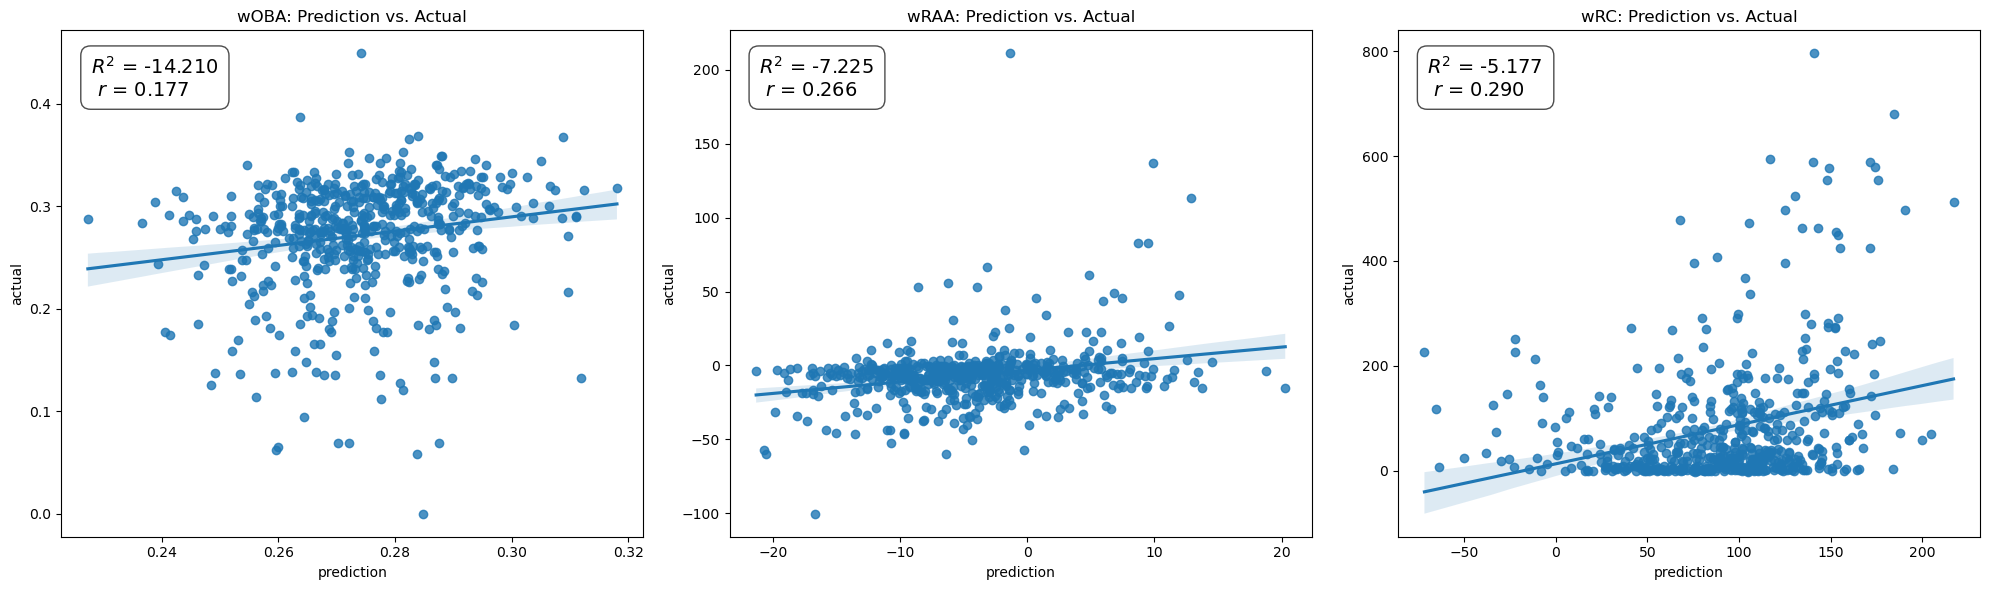

In [13]:
def lr_model(X: pd.DataFrame, y: pd.DataFrame) -> List:
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.3, random_state=42
    )

    model = LinearRegression()

    model.fit(X_train, y_train)

    preds = model.predict(X_test)

    return pd.DataFrame({"prediction": preds, "actual": y_test.values})


wOBA_preds = lr_model(X, df["major_wOBA"])
wRAA_preds = lr_model(X, df["major_wRAA"])
wRC_preds = lr_model(X, df["major_wRC"])

# Calculate R^2 values and Pearson R values
wOBA_r2_score = r2_score(wOBA_preds["prediction"], wOBA_preds["actual"])
wRAA_r2_score = r2_score(wRAA_preds["prediction"], wRAA_preds["actual"])
wRC_r2_score = r2_score(wRC_preds["prediction"], wRC_preds["actual"])

wOBA_pearson_r = scipy.stats.pearsonr(wOBA_preds["prediction"], wOBA_preds["actual"])[0]
wRAA_pearson_r = scipy.stats.pearsonr(wRAA_preds["prediction"], wRAA_preds["actual"])[0]
wRC_pearson_r = scipy.stats.pearsonr(wRC_preds["prediction"], wRC_preds["actual"])[0]

# Define subplots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Define annotation position
x_pos, y_pos = 0.05, 0.95

# --- 1. wOBA Plot ---
sns.regplot(data=wOBA_preds, x="prediction", y="actual", ax=axes[0])
axes[0].set_title("wOBA: Prediction vs. Actual")
axes[0].text(
    x_pos,
    y_pos,
    f"$R^2$ = {wOBA_r2_score:.3f} \n $r$ = {wOBA_pearson_r:.3f}",
    transform=axes[0].transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7),
)

# --- 2. wRAA Plot ---
sns.regplot(data=wRAA_preds, x="prediction", y="actual", ax=axes[1])
axes[1].set_title("wRAA: Prediction vs. Actual")
axes[1].text(
    x_pos,
    y_pos,
    f"$R^2$ = {wRAA_r2_score:.3f} \n $r$ = {wRAA_pearson_r:.3f}",
    transform=axes[1].transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7),
)

# --- 3. wRC Plot ---
sns.regplot(data=wRC_preds, x="prediction", y="actual", ax=axes[2])
axes[2].set_title("wRC: Prediction vs. Actual")
axes[2].text(
    x_pos,
    y_pos,
    f"$R^2$ = {wRC_r2_score:.3f} \n $r$ = {wRC_pearson_r:.3f}",
    transform=axes[2].transAxes,
    fontsize=14,
    verticalalignment="top",
    bbox=dict(boxstyle="round,pad=0.5", facecolor="white", alpha=0.7),
)

plt.tight_layout()
plt.show()

As we can see, the traditional batter data is not a good predictor for the translation of minor league performance to major league performance. This is why more advanced stats such as HardHit%, Launch Angle, Bat Speed, and other from StatCast is crucial for this evaluation.